In [ ]:
from google.colab import files
uploaded = files.upload()


Saving vanet_traffic_data.csv to vanet_traffic_data.csv


Shape: (195714, 27)

Columns:
 ['timestamp', 'road_segment_id', 'avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 'acceleration_directionality', 'weather_factor', 'label']

Data types:
 timestamp                         object
road_segment_id                   object
avg_speed_kmph                   float64
density_veh_per_km               float64
avg_wait_time_s                  float64
occupancy_pct                    float64
flow_veh_per_hr                  float64
queue_length_veh                 float64
avg_accel_ms2                    float64
heading_deg                      float64
signal_state_num

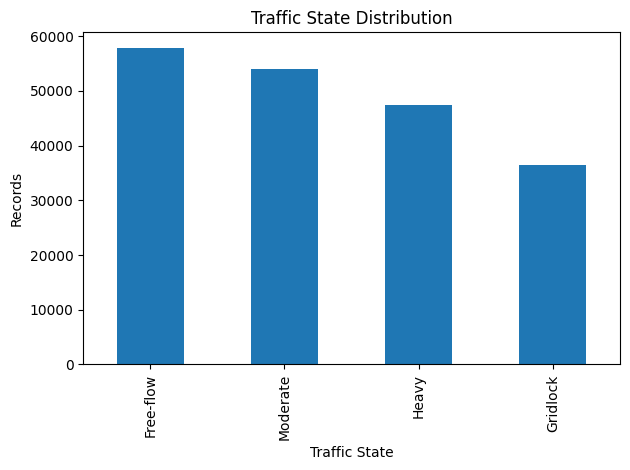

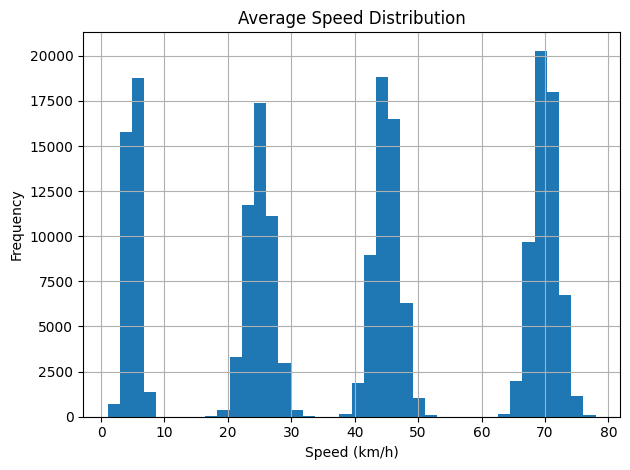

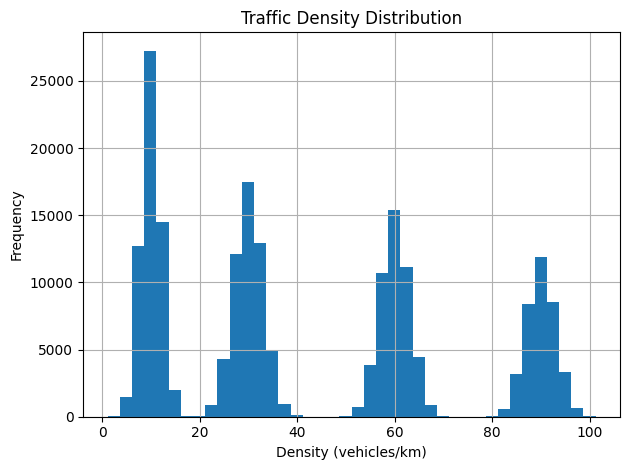

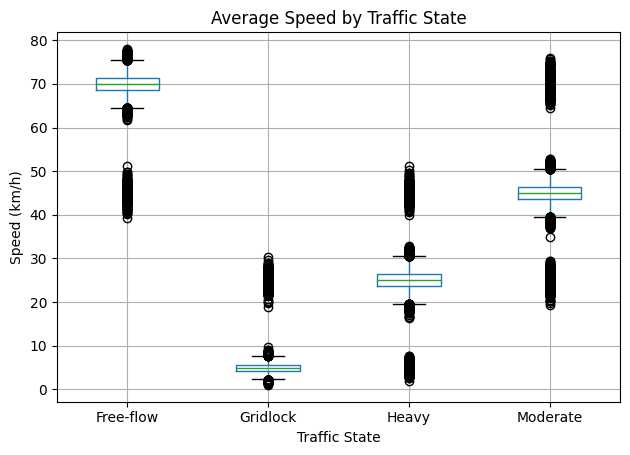

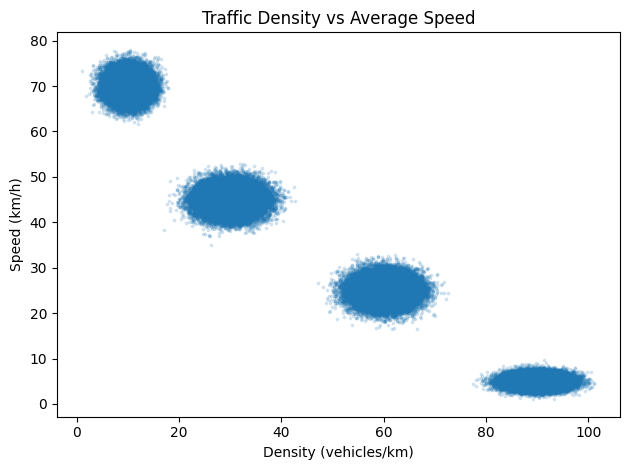


Correlation matrix:
                        avg_speed_kmph  density_veh_per_km  avg_wait_time_s  \
avg_speed_kmph                   1.000              -0.980           -0.920   
density_veh_per_km              -0.980               1.000            0.958   
avg_wait_time_s                 -0.920               0.958            1.000   
occupancy_pct                   -0.993               0.985            0.924   
flow_veh_per_hr                  0.986              -0.994           -0.958   
queue_length_veh                -0.921               0.958            0.992   
channel_busy_ratio_pct          -0.982               0.993            0.960   
avg_comm_delay_ms               -0.944               0.974            0.994   
packet_loss_pct                 -0.948               0.979            0.987   
congestion_pressure             -0.862               0.918            0.989   

                        occupancy_pct  flow_veh_per_hr  queue_length_veh  \
avg_speed_kmph                 -0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("vanet_traffic_data.csv")

# 1. Basic structure
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# 2. Numerical summary
print("\nDescriptive statistics:")
print(df.describe().T)

# 3. Categorical analysis
print("\nTraffic-state counts:")
print(df["label"].value_counts())

print("\nTraffic-state percentages:")
print(df["label"].value_counts(normalize=True).mul(100).round(2))

# 4. EDA plots
df["label"].value_counts().reindex(
    ["Free-flow", "Moderate", "Heavy", "Gridlock"]
).plot(kind="bar", title="Traffic State Distribution")
plt.xlabel("Traffic State")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

df["avg_speed_kmph"].hist(bins=40)
plt.title("Average Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df["density_veh_per_km"].hist(bins=40)
plt.title("Traffic Density Distribution")
plt.xlabel("Density (vehicles/km)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df.boxplot(column="avg_speed_kmph", by="label")
plt.suptitle("")
plt.title("Average Speed by Traffic State")
plt.xlabel("Traffic State")
plt.ylabel("Speed (km/h)")
plt.tight_layout()
plt.show()

plt.scatter(df["density_veh_per_km"], df["avg_speed_kmph"], s=3, alpha=0.15)
plt.title("Traffic Density vs Average Speed")
plt.xlabel("Density (vehicles/km)")
plt.ylabel("Speed (km/h)")
plt.tight_layout()
plt.show()

# 5. Correlation
main_cols = [
    "avg_speed_kmph", "density_veh_per_km", "avg_wait_time_s",
    "occupancy_pct", "flow_veh_per_hr", "queue_length_veh",
    "channel_busy_ratio_pct", "avg_comm_delay_ms", "packet_loss_pct",
    "congestion_pressure"
]
print("\nCorrelation matrix:")
print(df[main_cols].corr().round(3))